In [73]:
!pip install seaborn

In [74]:
#convention is to load pandas as pd.
import pandas as pd
#import numpy as np

#for visualisations,seaborn library is used for statistical graphs
import seaborn as sns

#matplotlib creates plots/graphs.
import matplotlib.pyplot as plt


In [75]:
#import the data
data =pd.read_csv('GFP_database.csv', encoding = 'latin1')
data.head(2)

,Area Abbreviation,Area Code,Area,Item Code,Item,Element Code,Element,Unit,latitude,longitude,...,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013
0,AF,2,Afghanistan,2511,Wheat and products,5142,Food,1000 tonnes,33.94,67.71,...,3249.0,3486.0,3704.0,4164.0,4252.0,4538.0,4605.0,4711.0,4810,4895
1,AF,2,Afghanistan,2805,Rice (Milled Equivalent),5142,Food,1000 tonnes,33.94,67.71,...,419.0,445.0,546.0,455.0,490.0,415.0,442.0,476.0,425,422


In [76]:
data.shape

(21477, 63)

In [77]:
data.dtypes

Area Abbreviation        str
Area Code              int64
Area                     str
Item Code              int64
Item                     str
                      ...   
Y2009                float64
Y2010                float64
Y2011                float64
Y2012                  int64
Y2013                  int64
Length: 63, dtype: object

In [78]:
#1. clean up the columns
data.isnull().sum()

Area Abbreviation    121
Area Code              0
Area                   0
Item Code              0
Item                   0
                    ... 
Y2009                104
Y2010                104
Y2011                104
Y2012                  0
Y2013                  0
Length: 63, dtype: int64

In [79]:
#since the amount of missing data is only 104 rows out of 21,000.  REmove the Null values in each row
#change dataframe by dropping null values.

data = data.dropna()
data.head(3)

,Area Abbreviation,Area Code,Area,Item Code,Item,Element Code,Element,Unit,latitude,longitude,...,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013
0,AF,2,Afghanistan,2511,Wheat and products,5142,Food,1000 tonnes,33.94,67.71,...,3249.0,3486.0,3704.0,4164.0,4252.0,4538.0,4605.0,4711.0,4810,4895
1,AF,2,Afghanistan,2805,Rice (Milled Equivalent),5142,Food,1000 tonnes,33.94,67.71,...,419.0,445.0,546.0,455.0,490.0,415.0,442.0,476.0,425,422
2,AF,2,Afghanistan,2513,Barley and products,5521,Feed,1000 tonnes,33.94,67.71,...,58.0,236.0,262.0,263.0,230.0,379.0,315.0,203.0,367,360


In [80]:
#1. clean up the columns
data.isnull().sum()

Area Abbreviation    0
Area Code            0
Area                 0
Item Code            0
Item                 0
                    ..
Y2009                0
Y2010                0
Y2011                0
Y2012                0
Y2013                0
Length: 63, dtype: int64

## Selecting certain data

In [81]:
#Select 1 column to display - Exmaple Area. Use [] brackets.
data['Area'].head()

0    Afghanistan
1    Afghanistan
2    Afghanistan
3    Afghanistan
4    Afghanistan
Name: Area, dtype: str

In [82]:
# There are 2 options to display multiple columns.
#Option 1 - use the name of columns.
data[['Area','Element','Y1961']].head()

,Area,Element,Y1961
0,Afghanistan,Food,1928.0
1,Afghanistan,Food,183.0
2,Afghanistan,Feed,76.0
3,Afghanistan,Food,237.0
4,Afghanistan,Feed,210.0


In [83]:
#Option 2. Use 'iloc' selector to display multiple columns (using column numbers)
#use : to include all rows.
data.iloc[:,[2,4,10,11,12,13,14]].head(2)

,Area,Item,Y1961,Y1962,Y1963,Y1964,Y1965
0,Afghanistan,Wheat and products,1928.0,1904.0,1666.0,1950.0,2001.0
1,Afghanistan,Rice (Milled Equivalent),183.0,183.0,182.0,220.0,220.0


In [84]:
#change dtypes from floats to int.
data = data.astype({'Y1961': 'int'})
data.dtypes

Area Abbreviation        str
Area Code              int64
Area                     str
Item Code              int64
Item                     str
                      ...   
Y2009                float64
Y2010                float64
Y2011                float64
Y2012                  int64
Y2013                  int64
Length: 63, dtype: object

In [85]:
#Total sum the column 1961.
data['Y1961'].sum()

np.int64(3501840)

In [86]:
#Total mean for Y1961 data.
data['Y1961'].mean()

np.float64(196.54487287422126)

In [87]:
#to select rows - first 10 rows & all the columns
data.iloc[0:10, :].head(1)

,Area Abbreviation,Area Code,Area,Item Code,Item,Element Code,Element,Unit,latitude,longitude,...,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013
0,AF,2,Afghanistan,2511,Wheat and products,5142,Food,1000 tonnes,33.94,67.71,...,3249.0,3486.0,3704.0,4164.0,4252.0,4538.0,4605.0,4711.0,4810,4895


In [88]:
#to select rows - row 123 to 1570 & all the columns
data.iloc[123:1570, :].head(1)

,Area Abbreviation,Area Code,Area,Item Code,Item,Element Code,Element,Unit,latitude,longitude,...,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013
123,AL,3,Albania,2574,Rape and Mustard Oil,5142,Food,1000 tonnes,41.15,20.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [89]:
#to select rows - row 123 to 1570 & columns 2 to 4
data.iloc[123:1570, 2:4].head(3)

,Area,Item Code
123,Albania,2574
124,Albania,2577
125,Albania,2580


In [90]:
#Another option is to use names.
data[data['Area']== 'Ireland'].head(2)

,Area Abbreviation,Area Code,Area,Item Code,Item,Element Code,Element,Unit,latitude,longitude,...,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013
9533,IE,104,Ireland,2511,Wheat and products,5521,Feed,1000 tonnes,53.41,-8.24,...,968.0,976.0,902.0,685.0,1063.0,804.0,783.0,760.0,650,600
9534,IE,104,Ireland,2511,Wheat and products,5142,Food,1000 tonnes,53.41,-8.24,...,395.0,423.0,501.0,449.0,470.0,493.0,512.0,502.0,494,500


In [91]:
#Select the country 'Ireland' an only the columns for Element, Years 2008 & 2009.
#Use .loc when you want to slect data by names/labels & rows & columns.

Ire_result = data.loc[data['Area']== 'Ireland',['Element','Area','Y2008','Y2009']]

In [92]:
#Use .iloc when you want to select data by column number.
Ire_result.iloc[0:5,:]

,Element,Area,Y2008,Y2009
9533,Feed,Ireland,1063.0,804.0
9534,Food,Ireland,470.0,493.0
9535,Feed,Ireland,5.0,4.0
9536,Food,Ireland,14.0,15.0
9537,Feed,Ireland,1242.0,1290.0


<Axes: >

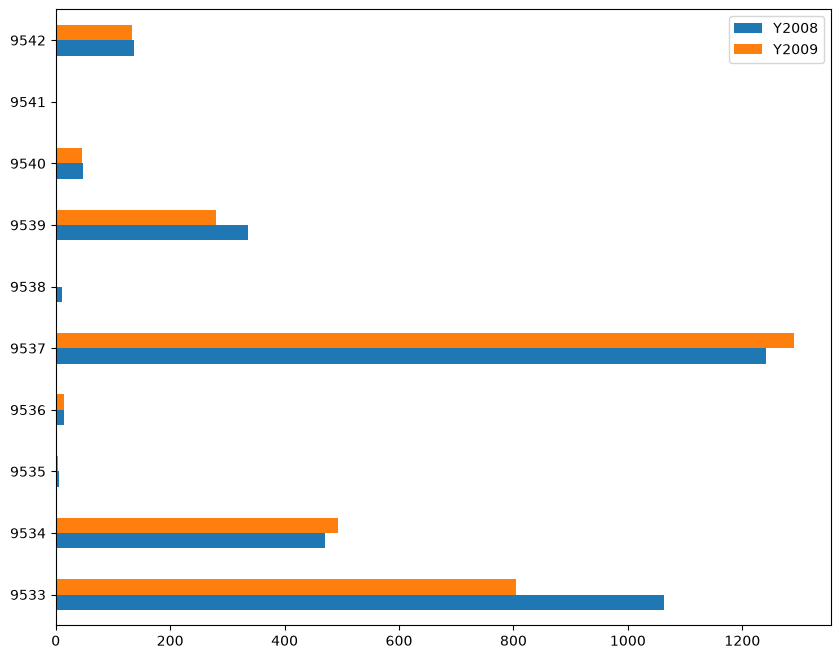

In [93]:
#Only the first 20 rows of Irish data
Ire_top10 = Ire_result.head(10)
#plot a horizontal bar chart
Ire_top10.plot(kind ='barh', figsize=(10,8)) 

<Axes: ylabel='Element'>

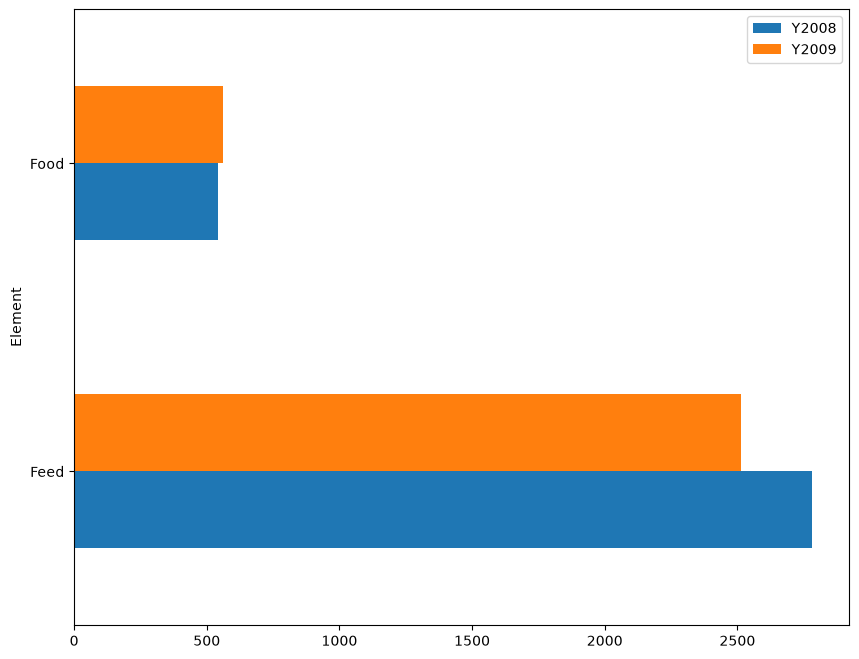

In [94]:
#Groupby is one of the most methods to select data.
Ire_top10.groupby('Element')[['Y2008','Y2009']].sum().plot(kind='barh',figsize=(10,8))